In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=12")
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for parent in [repo_root, *repo_root.parents]:
    src = parent / "src"
    if (src / "gwemfish").is_dir():
        sys.path.insert(0, str(src))
        break

import matplotlib.pyplot as plt

from gwemfish.simple_pipeline import (
    _deep_merge_dict,
    make_default_cfg,
    plot_system_observation,
    setup_em_observation,
    setup_gw_observation,
    run_inference, 
    plot_posterior, 
    to_source_plane_samples, 
    plot_source_posterior,
)
#
#OUTPUT_DIR = os.path.join("examples", "outputs", "simple_pipeline_demonstration")
#os.makedirs(OUTPUT_DIR, exist_ok=True)
#print("OUTPUT_DIR:", os.path.abspath(OUTPUT_DIR))

In [3]:
from gwemfish.config import DEFAULT_KWARGS_NUMERICS, SOLVER_PARAMS
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sample_cfg = {
    "em": {
        "pixel_grid_kwargs": {"npix": int(40), "pix_scl": 0.1},
        "psf_kwargs": {"psf_type": "GAUSSIAN", "fwhm": 0.4, "pixel_size": 0.1},#0.067
        "noise_simu_kwargs": {"npix": int(40), "background_rms": 5e-2, "exposure_time": 2200},
        "noise_inf_kwargs": {"npix": int(40), "background_rms": None, "exposure_time": 2200},
        "kwargs_numerics": DEFAULT_KWARGS_NUMERICS,
        "exposure_time": 2200,
        "seed": 87651,
        "source_pos": (0.0, 0.0), #Is this the position of the source of the GW or the position of the center of the source galaxy?
        "kwargs_source": [
            {
                "amp": 250,
                "R_sersic": 0.4,
                "n_sersic": 4.0,
                "e1": 0,
                "e2": 0,
                "center_x": 0.0, #same question for these center_x and y values
                "center_y": 0.0,
            }
        ],
        "kwargs_lens_light": [
            {
                "amp": 50.0,
                "R_sersic": 2.0,
                "n_sersic": 4.0,
                "e1": 0.0,
                "e2": 0.0,
                "center_x": 0.0,
                "center_y": 0.0,
            }
        ],
    },
    "lens": {
        "lens_model_list": ["EPL", "SHEAR"],
        "kwargs_lens": [
            {
                "theta_E": 1.2,
                "e1": 0.0,
                "e2": 0.1,
                "gamma": 2.0,
                "center_x": 0.0,
                "center_y": 0.0,
            },
            {"gamma1": 0.1, "gamma2": 0.0, "ra_0": 0.0, "dec_0": 0.0},
        ],
        "zl": 0.7,
        "zs": 1.5,
    },
    "gw": {
        "source_pos": (0.0, 0.0),
        "solver_params": SOLVER_PARAMS,
        "image_box_half_width": 10.6,
        "error_scales": {
            "sigma_td": 0.05,
            "sigma_dL_eff": 3.0,
            "epsilon": 0.005,
        },
    },
    "plot": {"plot_mode": "groupwise", "save_path": None, "save_tag": None, "hist_kwargs": {"density": True}},
    "source_plane": {"filter_std": None, "use_filtered": False},
    "output": {
        "output_dir": OUTPUT_DIR,
        "save_samples_path": None,
        "save_truths_path": None,
        "save_source_samples_path": None,
        "save_system_plot_path": None,
        "json_path": None,
    },
}

def q_pa_to_e1e2(q, pa):
    e = (1-q) / (1+q)
    e1 = float(e * np.cos(2*pa))
    e2 = float(e * np.sin(2*pa))
    return (e1, e2)

def mag_to_amp(mag_value):
    """
    convert between the apparent magnitude in the catalog to Sersic amplitude
    """
    return 60 #for now

    

In [6]:
from lenstronomy.Util import param_util
from lenstronomy.SimulationAPI.mag_amp_conversion import MagAmpConversion

In [7]:
import copy

def row_to_cfg(row, sample_cfg, gw_enabled):
    """
    Convert one row of the Qiuhan's sky catalog into a GWEMFISH configuration.

    Parameters
    ----------
    row : pandas.Series
        One row of the lens catalog.

    sample_cfg : dict
        Reference GWEMFISH config.

    Returns
    -------
    cfg : dict
        GWEMFISH configuration for this lens system.
    """

    cfg = copy.deepcopy(sample_cfg)

    # ==========================================================
    # Convert axis ratio + PA -> ellipticity
    # ==========================================================

    # --- 1. PREPARE LENS (DEFLECTOR) LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])


    kwargs_lens_light_mag = [{
    'magnitude': row['deflector_app_mag_VIS'],
    'R_sersic': row['deflector_Re'],
    'n_sersic': 4.0,  # Standard assumption for elliptical lens galaxies
    'e1': lens_e1, 'e2': lens_e2,
    'center_x': 0, 'center_y': 0
    }]

    # --- 2. PREPARE SOURCE LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    source_e1, source_e2 = param_util.phi_q2_ellipticity(phi=row['source_pa'], q=row['source_q'])
    
    # Choose your band (e.g., VIS)
    kwargs_source_mag = [{
        'magnitude': row['source_app_mag_VIS'], 
        'R_sersic': row['source_Re'],
        'n_sersic': row['source_sersic_index'],
        'e1': source_e1, 'e2': source_e2,
        'center_x': row['source_relative_x'], 
        'center_y': row['source_relative_y']
    }]
    
    # --- 3. CONVERT BOTH TO AMP ---
    # Define your model profile types
    kwargs_model = {
        'lens_light_model_list': ['SERSIC_ELLIPSE'],
        'source_light_model_list': ['SERSIC_ELLIPSE']
    }
    
    # Initialize the converter with your survey zero-point
    mag_converter = MagAmpConversion(kwargs_model=kwargs_model, magnitude_zero_point=25.9)
    
    # Get the final dictionaries containing the calculated 'amp' keys
    lens_light_amp = mag_converter.magnitude2amplitude(kwargs_lens_light_mag=kwargs_lens_light_mag)
    source_amp = mag_converter.magnitude2amplitude(kwargs_source_mag=kwargs_source_mag)
    
    #print(lens_light_amp)
    #print(source_amp)
    
    #source_e1, source_e2 = q_pa_to_e1e2(
     #   row["source_q"],
      #  row["source_pa"],
   # )

    lens_pos = (float(row['deflector_ra']), float(row['deflector_dec']))
    
    source_pos = (float(row["source_relative_x"]), float(row["source_relative_y"]))

    # ==========================================================
    # Lens geometry
    # ==========================================================

    cfg["lens"]["zl"] = float(row["deflector_z"])
    cfg["lens"]["zs"] = float(row["source_z"])

    # ==========================================================
    # Lens mass model (EPL)
    # ==========================================================

    cfg["lens"]["kwargs_lens"][0]["theta_E"] = float(row["deflector_thetaE"])
    cfg["lens"]["kwargs_lens"][0]["gamma"] = float(row["deflector_slope"])

    cfg["lens"]["kwargs_lens"][0]["e1"] = float(lens_e1)
    cfg["lens"]["kwargs_lens"][0]["e2"] = float(lens_e2)

    cfg["lens"]["kwargs_lens"][0]["center_x"] = 0.00
    cfg["lens"]["kwargs_lens"][0]["center_y"] = 0.00

    # ==========================================================
    # External shear
    # ==========================================================

    cfg["lens"]["kwargs_lens"][1]["gamma1"] = float(row["deflector_shear1"])
    cfg["lens"]["kwargs_lens"][1]["gamma2"] = float(row["deflector_shear2"])

    cfg["lens"]["kwargs_lens"][1]["ra_0"] = 0.00
    cfg["lens"]["kwargs_lens"][1]["dec_0"] = 0.00

    # ==========================================================
    # Source light
    # ==========================================================

    cfg["em"]["kwargs_source"][0]["R_sersic"] = float(row["source_Re"])
    cfg["em"]["kwargs_source"][0]["n_sersic"] = float(row["source_sersic_index"])

    cfg["em"]["kwargs_source"][0]["e1"] = float(source_e1)
    cfg["em"]["kwargs_source"][0]["e2"] = float(source_e2)

    cfg["em"]["kwargs_source"][0]["center_x"] = source_pos[0]
    cfg["em"]["kwargs_source"][0]["center_y"] = source_pos[1]

    cfg["em"]["kwargs_source"][0]["amp"] = float(source_amp[1][0]['amp'])

    # ==========================================================
    # Lens light
    # ==========================================================

    cfg["em"]["kwargs_lens_light"][0]["R_sersic"] = float(row["deflector_Re"])
    cfg["em"]["kwargs_lens_light"][0]["n_sersic"] = float(4)

    cfg["em"]["kwargs_lens_light"][0]["e1"] = float(lens_e1)
    cfg["em"]["kwargs_lens_light"][0]["e2"] = float(lens_e2)

    cfg["em"]["kwargs_lens_light"][0]["center_x"] = 0.00
    cfg["em"]["kwargs_lens_light"][0]["center_y"] = 0.00

    cfg["em"]["kwargs_lens_light"][0]["amp"] = float(lens_light_amp[0][0]['amp'])

    # ==========================================================
    # GW source position
    # ==========================================================
    cfg["em"]["source_pos"] = source_pos
    
    if gw_enabled is True:
        cfg["gw"]["source_pos"] = (source_pos[0]+0.005, source_pos[1]-0.005)

    if gw_enabled is False:
        cfg["gw"] = {"enabled": False}

    return cfg

## Prepare to implement data

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('../../data_catalog/Qiuhan/Euclid_cats/filtered_lens_catalog_PL_IC_gt_70.csv')

In [10]:
df.columns

Index(['deflector_ra', 'deflector_dec', 'deflector_z', 'deflector_q',
       'deflector_pa', 'deflector_vdisp', 'deflector_rband_abs_mag',
       'deflector_Re', 'deflector_thetaE', 'deflector_thetaE_autolens',
       'deflector_slope', 'deflector_einstein_mass', 'deflector_shear1',
       'deflector_shear2', 'source_z', 'source_max_image_multiplicity',
       'source_ra', 'source_dec', 'source_relative_x', 'source_relative_y',
       'source_pa', 'source_q', 'source_Re', 'source_sersic_index',
       'source_mStar', 'source_SFR_100', 'source_metallicity',
       'deflector_app_mag_VIS', 'source_app_mag_VIS', 'source_app_mag_F106',
       'source_app_mag_F129', 'source_app_mag_F158', 'source_app_mag_g',
       'source_app_mag_r', 'source_app_mag_i', 'source_app_mag_z', 'IC_Euclid',
       'IC_CSST', 'IC_Roman', 'IC_nofactor_Euclid', 'IC_nofactor_CSST',
       'IC_nofactor_Roman', 'origin_batch'],
      dtype='str')

In [11]:
source_galaxy = df.iloc[536:537]

In [12]:
row = source_galaxy.iloc[0]
cfg_gw_source = row_to_cfg(row, sample_cfg, True)
cfg_gw_source["use_parameter_layout"] = True

cfg_gw_source['gw']['source_pos'] = (cfg_gw_source['gw']['source_pos'][0]-0.005, cfg_gw_source['gw']['source_pos'][1]+0)

In [13]:
cfg_gw_source['em']

{'pixel_grid_kwargs': {'npix': 40, 'pix_scl': 0.1},
 'psf_kwargs': {'psf_type': 'GAUSSIAN', 'fwhm': 0.4, 'pixel_size': 0.1},
 'noise_simu_kwargs': {'npix': 40,
  'background_rms': 0.05,
  'exposure_time': 2200},
 'noise_inf_kwargs': {'npix': 40,
  'background_rms': None,
  'exposure_time': 2200},
 'kwargs_numerics': {'supersampling_factor': 1},
 'exposure_time': 2200,
 'seed': 87651,
 'source_pos': (0.0071626113808065, 0.1307109188318556),
 'kwargs_source': [{'amp': 2.832040322058021,
   'R_sersic': 0.3634539737664958,
   'n_sersic': 0.6975706262087478,
   'e1': -0.27827000010569725,
   'e2': -0.08730415816825296,
   'center_x': 0.0071626113808065,
   'center_y': 0.1307109188318556}],
 'kwargs_lens_light': [{'amp': 2.807348984458816,
   'R_sersic': 0.6705098162802311,
   'n_sersic': 4.0,
   'e1': 0.07653407928269305,
   'e2': -0.03218846653138091,
   'center_x': 0.0,
   'center_y': 0.0}]}

#changing to be compatible with HST
cfg_gw_source['em']['pixel_grid_kwargs']['npix'] = 100
cfg_gw_source['em']['pixel_grid_kwargs']['pix_scl'] = 0.04

cfg_gw_source['em']['psf_kwargs']['fwhm'] = 0.075
cfg_gw_source['em']['psf_kwargs']['pixel_size'] = 0.04

cfg_gw_source['em']['noise_simu_kwargs']['npix'] = 100
cfg_gw_source['em']['noise_inf_kwargs']['npix'] = 100

#cfg_gw_source['em']['kwargs_numerics']['supersampling_factor'] = 3

#Made compatible with Euclid
cfg_gw_source['em']['pixel_grid_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_simu_kwargs']['npix'] = 60
cfg_gw_source['em']['noise_inf_kwargs']['npix'] = 60
cfg_gw_source['em']['psf_kwargs']['fwhm'] = 0.16

cfg_gw_source['em']['kwargs_source'][0]['amp'] = 200

In [14]:
cfg_gw_source['em']['kwargs_lens_light'][0]['amp'] = 0

In [17]:
ctx_gw_source = setup_em_observation(cfg=cfg_gw_source)

ctx_gw_source = setup_gw_observation(ctx_gw_source, cfg=cfg_gw_source)

In [18]:
tp = ctx_gw_source['truth_params']

In [19]:
tp

{'source_amp': 2.832040322058021,
 'source_R_sersic': 0.3634539737664958,
 'source_n': 0.6975706262087478,
 'source_e1': -0.27827000010569725,
 'source_e2': -0.08730415816825296,
 'source_center_x': 0.0071626113808065,
 'source_center_y': 0.1307109188318556,
 'light_amp': 0.0,
 'light_R_sersic': 0.6705098162802311,
 'light_n': 4.0,
 'light_e1': 0.07653407928269305,
 'light_e2': -0.03218846653138091,
 'light_center_x': 0.0,
 'light_center_y': 0.0,
 'noise_sigma_bkg': 0.05,
 'x_image_true_em': Array([-0.1181847 ,  0.18938637,  0.98209515, -0.88867839], dtype=float64),
 'y_image_true_em': Array([ 1.66625603, -1.27762328, -0.32969538, -0.40465601], dtype=float64),
 'lens0_gamma': 1.7647035413115852,
 'lens0_theta_E': 1.219185605485679,
 'lens0_e1': 0.07653407928269305,
 'lens0_e2': -0.03218846653138091,
 'lens0_center_x': 0.0,
 'lens0_center_y': 0.0,
 'lens1_gamma1': -0.1053066977536867,
 'lens1_gamma2': -0.0499436370338794,
 'lens1_ra_0': 0.0,
 'lens1_dec_0': 0.0,
 'source0_amp': 2.832040

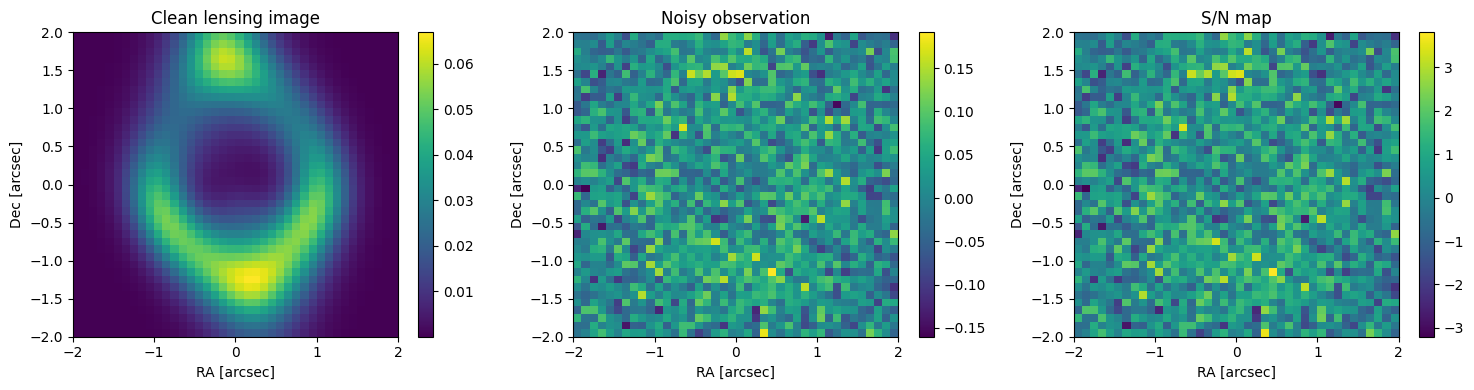

In [20]:
fig = plot_system_observation(
    ctx_gw_source,
    cfg={"output": {"save_system_plot_path": None}} #os.path.join(OUTPUT_DIR, "system_observation.png")}},
)
plt.show()

In [20]:
from gwemfish import simulate_in_pal, plot_system_observation_pal, save_pal_outputs
OUT = "examples/outputs/pal_mirror"
ctx_pal = simulate_in_pal(ctx_gw_source)
plot_system_observation_pal(ctx_pal, cfg={"output": {"output_dir": OUT, "save_pal_dataset_plot_path": "dataset_subplot.png", "save_pal_tracer_plot_path": "tracer.png"}, "plot": {"pal_dataset": "both"}})
save_pal_outputs(ctx_pal, OUT, dataset="both")

/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/autoconf/workspace.py:173: UserWarning: Cannot verify the workspace at /Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/other_trials/IC_Values matches the installed library version (2026.6.30.644): no `version.workspace_version` key in config/general.yaml and no version.txt at the workspace root.

If you cloned the workspace from `main` rather than a release tag, set `version.workspace_version_check: False` in config/general.yaml to silence this warning. The `main` branch updates more frequently than library releases, so version mismatches are expected and not actionable for `main`-branch users.

You can also set the environment variable PYAUTO_SKIP_WORKSPACE_VERSION_CHECK=1 to disable temporarily.
  warnings.warn(_missing_version_warning(root, library_version))


2026-09-13 20:04:11,499 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 1600 image-pixels


/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/.venv/lib/python3.13/site-packages/autoarray/operators/convolver.py:951: UserWarning: No blurring_image provided. Only the direct image will be convolved. This may change the correctness of the PSF convolution.
  warnings.warn(


## Compute IC Values

In [49]:
#Option A - use SNR_expected = I_clean / sigma_noise

image_clean = ctx_gw_source["lens_image"].model(
    kwargs_lens=ctx_gw_source["kwargs_lens"],
    kwargs_source=ctx_gw_source["cfg"]["em"]["kwargs_source"],
    kwargs_lens_light=[
        {
            **ctx_gw_source["cfg"]["em"]["kwargs_lens_light"][0],
            "amp": 0.0,
        }
    ],
)

background_rms = ctx_gw_source["cfg"]["em"]["noise_simu_kwargs"]["background_rms"]
exposure_time = ctx_gw_source["cfg"]["em"]["exposure_time"]

noise_map = np.sqrt(
    background_rms**2
    + np.clip(np.asarray(image_clean), 0.0, None) / exposure_time
)

snr_map_expected = np.asarray(image_clean) / noise_map

mask_expected = snr_map_expected > 2.0
N_pix_expected = np.sum(mask)

In [54]:
#Option B - use SNR = I_noisy / sigma_noise (what GWEMFish plot currently uses to plot the snr_map in plot_system_observation)

data = ctx_gw_source["em_obs"]["data"] #this is the actualy noisy I instead of the clean image

snr_map = np.asarray(data) / noise_map

mask = snr_map > 2.0
N_pix = np.sum(mask)

Which would be more suitable in this case? Option A or option B?


In [41]:
pixel_scale = ctx_gw_source["cfg"]["em"]["pixel_grid_kwargs"]["pix_scl"]

A = N_pix * pixel_scale**2

In [42]:
FWHM = ctx_gw_source["cfg"]["em"]["psf_kwargs"]["fwhm"]

R_E = ctx_gw_source["truth_params"]["lens0_theta_E"]

r_s_eff = ctx_gw_source["truth_params"]["source_R_sersic"]

In [43]:
print("max clean:", np.max(image_clean))
print("max expected SNR:", np.max(snr_map_expected))
print("pixels > 2:", N_pix)
print("A:", A)

max clean: 0.06684584987162365
max expected SNR: 1.3288660062905517
pixels > 2: 89
A: 0.8900000000000001


In [44]:
IC_joint = (
    A / FWHM**2
) * (
    R_E / r_s_eff
)

In [45]:
IC_joint

np.float64(18.6590886879973)

In [47]:
source_galaxy.iloc[0]

deflector_ra                                9.437464
deflector_dec                               2.284971
deflector_z                                 1.173803
deflector_q                                 0.846675
deflector_pa                              332.809762
deflector_vdisp                           321.562028
deflector_rband_abs_mag                   -24.589218
deflector_Re                                 0.67051
deflector_thetaE                            1.219186
deflector_thetaE_autolens                   1.196932
deflector_slope                             1.764704
deflector_einstein_mass          782475254883.208984
deflector_shear1                           -0.105307
deflector_shear2                           -0.049944
source_z                                    2.928835
source_max_image_multiplicity                      2
source_ra                                  -0.054998
source_dec                                 -1.937589
source_relative_x                           0.

# Here we see a clear mismatch...